## 99 B-Line Duration Analysis

### Introduction

While taking the 99 B-Line to school, the duration of bus rides always felt inconsistent and longer than expected. As such, I wanted to look into if there were significant differences between the scheduled and actual bus times, and between days of the week. The results of this analysis can be used to evaluate the reliability of this bus line and inform future class-scheduling decisions. Overall, the aim of this project is to develop my skills in data collection, cleaning and analysis using Python packages and SQL queries in a topic relevant to my daily life.

### Data Collection and Management

I collected data from the public TransLink realtime API and compared it to the scheduled (static) data, both available on the TransLink website. Creating a data collection script within this repository, I fetched and parsed Protocol Buffer feeds into manageable csvs. Noteably, due to the constraint of 1000 pull requests per day, I limited my analysis within the morning (8am to 12pm) to ensure data was collected with sufficient accuracy. The script was run for a week.

Relevant variables to the analysis include:
* timestamp: integer of time the entry was recorded in a Unix timestamp
* stopId: integer of which stop the bus is currently headed to
* tripId: integer for each unique trip a bus takes from start to finish
* routeId: integer describing the route a bus is on
* directionId: factor describing direction, where 0 is East or North and 1 is West or South


To better manage the files, I created a local database to organize each day's data into their respective tables. Doing this would also allow me to query specific entries that were relevant to the analysis.



### Data Wrangling

#### SQL Querying

To complete the analysis, I needed to filter observations for only the Westbound 99 B-Line, specifically for determining the start and end times of each trip. This would be used to take the difference and obtain elapsed time of each trip. 

To do so, I imported SQLite for querying and pandas to work with final dataframes. In my initial data exploration, I noticed there were multiple timestamps per stop and trip, since data was collected periodically. Therefore I selected only the maximum timestamps grouped by stopId and tripId, and only the first and last stops of the Westbound 99 B-Lines. I also ensured that only trips with a recorded start and stop were included, then inner joined the tables. The result of this query was a dataframe of 3 variables for each day: max_timestamp, stopId, and tripId.

In [352]:
import pandas as pd
import sqlite3
import numpy as np

from matplotlib import pyplot as plt
from scipy import stats

In [353]:
dbconn = sqlite3.connect('location.db')
tables = list(pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", dbconn)['name'])

In [354]:
location_dfs = []

for table in tables:
    table_name = "\'" + table + "\'"
    
    sql_query = """
    SELECT DISTINCT MAX(F.timestamp) AS max_timestamp, F.stopId, G.tripId
    FROM (
        SELECT *
        FROM (
            SELECT MAX(timestamp) AS max_timestamp, stopId, [trip.tripId] AS tripId FROM %s
            WHERE [trip.routeId] = 6641 AND [trip.directionId] = 1 AND (stopId = 11606 OR stopId = 12483)
            GROUP BY tripId, stopId
            )
        GROUP BY tripId
        HAVING COUNT(*) = 2
        ) G
    INNER JOIN %s F ON F.[trip.tripId] = G.tripId
    WHERE F.stopId = 11606 OR F.stopId = 12483
    GROUP BY G.tripId, F.stopId
    ORDER BY tripId
    """ % (table_name, table_name)
    
    location_dfs.append(pd.read_sql_query(sql_query, dbconn))

In [355]:
location_dfs[0].head()

,max_timestamp,stopId,tripId
0,1776351675,11606,14898260
1,1776354503,12483,14898260
2,1776351851,11606,14898261
3,1776354509,12483,14898261
4,1776352088,11606,14898262


#### Transforming Timestamps into Delta Times

To obtain relevant elapsed times per trip, I converted the unix timestamps into the DateTime type, and created a new column per tripId for the end time by shifting the timestamps. The start and end times were then subtracted and converted to minutes for easier interpretation. The final dataframe includes two variables: tripId and delta_time_min.

In [356]:
delta_time_dfs = []

for df in location_dfs:
    delta_df = df
    
    delta_df['start_time'] = pd.to_datetime(delta_df['max_timestamp'], unit = 's', errors = 'coerce')
    delta_df['ending_time'] = delta_df.groupby('tripId')['start_time'].shift(-1)
    delta_df['delta_time'] = (delta_df['ending_time'] - delta_df['start_time'])
    delta_df = delta_df[pd.notnull(delta_df['delta_time'])]
    delta_df['delta_time_min'] = delta_df['delta_time'].dt.total_seconds().div(60)

    cleaned_df = delta_df[['tripId', 'delta_time_min']]
        
    delta_time_dfs.append(cleaned_df)

In [357]:
delta_time_dfs[0].head()

,tripId,delta_time_min
0,14898260,47.133333
2,14898261,44.300000
4,14898262,43.266667
6,14898263,40.666667
8,14898264,46.466667


### Question 1: Is the average 99 bus duration greater than the expected average of 41.3 minutes?

I conducted a one-sample t-test at a significance level of 0.05. To ensure independence, I performed two-stage cluster sampling such that for each day, 6 random samples were drawn. 

Given the static analysis data, we expect the average bus trip to take 41.3 minutes, thus our null hypothesis is h_0: μ = 41.3. The alternative hypothesis is h_1: μ ≠ 41.3.

We meet the conditions of the t-test:
* Random Sampling: Using two-stage cluster sampling
* Independence: Sample is less than 10% of all bus trips
* Normality: Since n = 36 > 30 and by independence, CLT applies

Thus, I used the SciPy package to conduct the one-sample t-test.

In [358]:
np.random.seed(70)

In [359]:
samples = []

for df in delta_time_dfs:
    sample = df.sample(n=6)
    samples.append(sample)

sampled_df = pd.concat(samples)
len(sampled_df)

36

In [360]:
h_0 = 41.3
t_stat, p_value = stats.ttest_1samp(sampled_df['delta_time_min'], h_0)
print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

T-statistic: -2.2859
P-value: 0.0284


The results show a t-statistic of -2.2859 and a P-value of 0.0284. At the 5% significance level, we reject the null hypothesis; there is sufficient evidence to say the true average trip time is different from 41.3 minutes.

To investigate this further, I used matplotlib to visualize boxplots between static and sampled durations. Interestingly, the median sampled time is acutally lower than the expected, which contrasts what I was expecting. To note, there are 2 very far outliers in the sample and the whiskers reach further than the static durations. 

Text(0, 0.5, 'Time (min)')

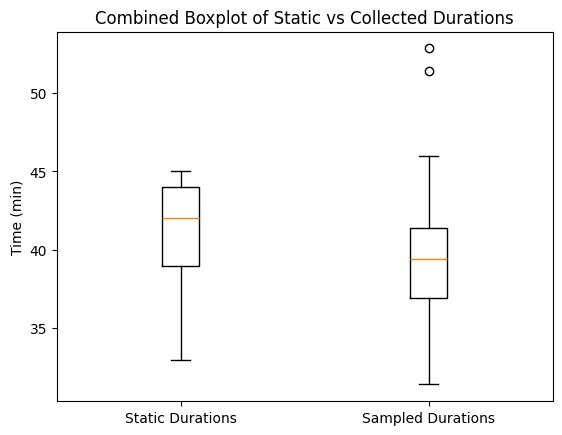

In [361]:
static_durations = pd.read_csv('../static_durations.csv')
plt.boxplot([static_durations['delta_time_min'], sampled_df['delta_time_min']], tick_labels = ["Static Durations", "Sampled Durations"])
plt.title('Combined Boxplot of Static vs Collected Durations')
plt.ylabel('Time (min)')

### Question 2: Is there a significant difference in durations between days of operation?

To investigate, I conducted ANOVA between each day of the week recorded at a 5% significance level. The null hypothesis H_0 is that the mean durations are all the same, while the alternative hypothesis H_1 is that there is a difference somewhere between groups. To address the conditions of ANOVA:

* Assume the variances of each day are approximately equal
* Each day is independent, and by sampling within groups, groups are independent

Using SciPy, I conducted a one-way ANOVA test with the sampled data:

In [362]:
np.random.seed(70)

In [363]:
isolated_arrays = []

for df in delta_time_dfs:
    isolated_array = df.sample(n=6)['delta_time_min']
    isolated_arrays.append(isolated_array)

f_stat, p_value = stats.f_oneway(*isolated_arrays)

print("F-statistic:", round(f_stat, 4))
print("P-value:", round(p_value, 4))


F-statistic: 5.0313
P-value: 0.0018


The test resulted in an F-statistic of 5.0313 and a P-value of 0.0018. Therefore at the 5% significance level, we reject the null hypothesis and can say there is enough evidence that there is a difference between some days of operation.

Again, by visualizing with side-by-side boxplots using matplotlib, we can see the differences across days. There is the general expected trend of a lower median on weekends and higher on weekdays, besides the exception of Wednesday, which may be due to sampling variablity. Thursday appears to be the busiest day with the highest median and upper whisker reaching above 50 minutes. Perhaps this illustrates the need to be wary on certain weekdays over others.

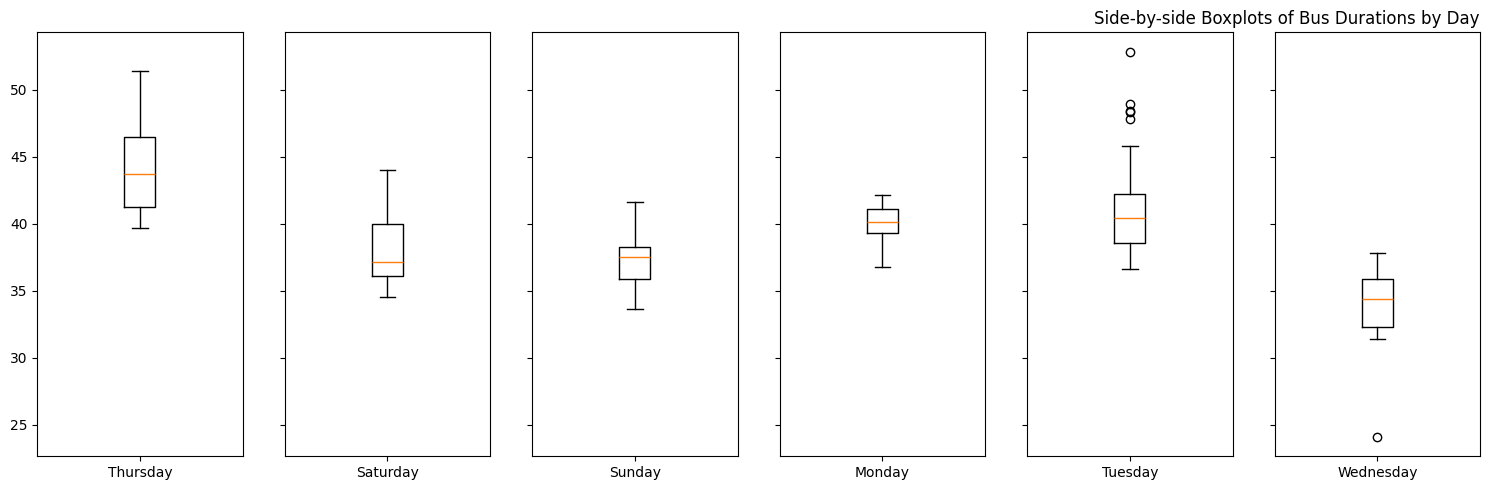

In [364]:
fig, ax = plt.subplots(ncols=6, sharey=True, figsize = (15,5))
plt.title('Side-by-side Boxplots of Bus Durations by Day', loc = 'right')
labels = ["Thursday", "Saturday", "Sunday", "Monday", "Tuesday", "Wednesday"]
index = 1
for df in delta_time_dfs:
    array = df['delta_time_min']
    plt.subplot(1, 6, index)
    plt.boxplot(array, tick_labels=[labels[index - 1]])
    
    index = index + 1
    
plt.tight_layout()

### Discussion

The hypothesis testing of comparison between static and real-time data showed statistically significant differences in both aspects at the 5% signifiance level. This somewhat aligned by my initial expectations, but the lower median of real-time data compared to static was the most shocking, as seen by the negative t-statistic. Additionally, we also saw trends between days of the week in the ANOVA analysis, noting that some weekdays had higher median times than others.

The results of this analysis reveal implications of what we can expect from bus times. On one hand, TransLink could reconsider their static bus schedules as they appear to differ from real times significantly. However, having a "buffer" in expected times allows for less complaints from commuters who see discrepancies (such as myself), which can be taken into account. Day-to-day comparisons may also be considered when planning trips around the 99 B-line, especially during weekdays.

Admittedly there were weaknesses to this analysis, specifically pertaining to data collection, that could be improved on for better accuracy. Due to the constraints of data collection by public API and file size, there was less opportunity to sample a wider variety of days; it would be helpful to have multiple weeks of data, but would take too much storage for the scope of this project. Doing so would also strengthen claims of independence and use of statistical inference. A future exploration I may also consider to mitigate this issue is also developing a machine learning algorithm to fetch data more productively. By using and analyzing past data collected, this method would reduce the need for an unnecessary amount of feed requests per minute, therefore expanding the hours collected daily. 

Future questions related to this topic may also be considered with different means of statistical analysis, including forecasting modelling. A prediction model of bus times with respect to time of day could be interesting to look into, seeing that there are significant differences. There are also better ways to utilize real-time API information as well, such as a continually updating dashboard to visualize data of currently moving buses. Overall, this project was an interesting way to explore technical skills in data analysis while applying statistical concepts learned in my coursework. There is a lot that can be done with public data and has been quite insightful.